In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [6]:
df = pd.read_csv("../data/processed/music_memory_processed.csv")

In [7]:
y = df["melody_span"]

In [9]:
X = df.drop(
    columns=[
        "digit_span",
        "spatial_span",
        "melody_span"
    ]
)


In [10]:
X.dtypes

age                                  int64
sex                                    str
years_of_education                   int64
country                                str
ses_nuclear_family                 float64
gold_msi_musical_training            int64
gold_msi_general_sophistication      int64
gold_msi_active_engagement           int64
bfi_extraversion                     int64
bfi_agreeableness                    int64
bfi_conscientiousness                int64
bfi_negative_emotionality            int64
bfi_open_mindedness                  int64
dtype: object

In [11]:
X = pd.get_dummies(
    X,
    columns=["sex", "country"],
    drop_first=True,
    dtype=int
)

In [12]:
X.dtypes

age                                  int64
years_of_education                   int64
ses_nuclear_family                 float64
gold_msi_musical_training            int64
gold_msi_general_sophistication      int64
gold_msi_active_engagement           int64
bfi_extraversion                     int64
bfi_agreeableness                    int64
bfi_conscientiousness                int64
bfi_negative_emotionality            int64
bfi_open_mindedness                  int64
sex_male                             int64
sex_nonbinary                        int64
country_Australia                    int64
country_Austria                      int64
country_Belgium                      int64
country_Brazil                       int64
country_Canada                       int64
country_Finland                      int64
country_France                       int64
country_Germany                      int64
country_Italy                        int64
country_Netherlands                  int64
country_Nor

In [13]:
X.head()


,age,years_of_education,ses_nuclear_family,gold_msi_musical_training,gold_msi_general_sophistication,gold_msi_active_engagement,bfi_extraversion,bfi_agreeableness,bfi_conscientiousness,bfi_negative_emotionality,...,country_Finland,country_France,country_Germany,country_Italy,country_Netherlands,country_Norway,country_Portugal,country_Spain,country_UK,country_USA
0,29,18,8.0,43,112,50,45,52,49,31,...,0,0,0,0,0,0,0,0,0,0
1,21,16,64.5,32,83,39,38,52,33,38,...,0,0,0,0,0,0,0,0,0,0
2,23,16,22.0,48,121,55,45,59,53,21,...,0,0,0,0,0,0,0,0,0,0
3,30,15,20.5,39,106,34,48,49,51,28,...,0,0,0,0,0,0,0,0,0,0
4,26,17,38.0,43,111,54,33,46,51,29,...,0,0,0,0,0,0,0,0,0,0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[0. ,0.17,0.04,...,3.67,1.33,1.53]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](28,)","['age','years_of_education','ses_nuclear_family',...,'country_Spain', 'country_UK','country_USA']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.63
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)


In [19]:
y_pred = model.predict(X_test)

In [20]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,29.5,29.575960
1,28.5,32.377483
2,18.5,19.932554
3,24.5,30.701795
4,22.5,27.652365
5,17.5,23.246253
6,19.5,23.116247
7,19.0,22.858379
8,19.5,26.695259
9,23.5,24.028152


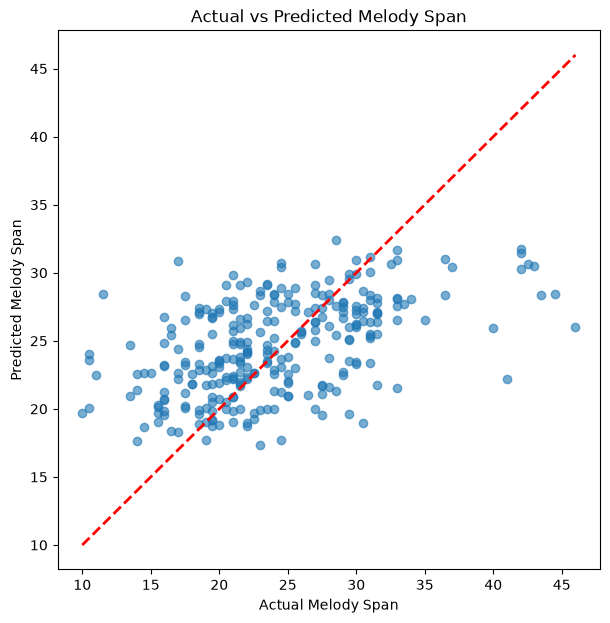

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Melody Span")
plt.ylabel("Predicted Melody Span")
plt.title("Actual vs Predicted Melody Span")

plt.show()